In [26]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [27]:
os.makedirs("fastf1_cache", exist_ok=True)

In [28]:
fastf1.Cache.enable_cache("fastf1_cache")

In [29]:
session = fastf1.get_session(2025, 3, 'R')
session.load()

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '44', '6', '23', '87', '14', '22', '10', '55', '7', '27', '30', '31', '5', '18']


In [30]:
laps = session.laps

In [31]:
ver_laps = laps.pick_drivers("VER")

In [32]:
ver_laps = ver_laps[ver_laps["LapTime"].notna()]

In [33]:
## CHECKING!
print(ver_laps[[
    "LapNumber",
    "LapTime",
    "Stint",
    "Compound",
    "PitInTime",
    "PitOutTime"
]].head(53))

    LapNumber                LapTime  Stint Compound              PitInTime  \
0         1.0 0 days 00:01:34.725000    1.0   MEDIUM                    NaT   
1         2.0 0 days 00:01:33.943000    1.0   MEDIUM                    NaT   
2         3.0 0 days 00:01:33.639000    1.0   MEDIUM                    NaT   
3         4.0 0 days 00:01:33.744000    1.0   MEDIUM                    NaT   
4         5.0 0 days 00:01:33.776000    1.0   MEDIUM                    NaT   
5         6.0 0 days 00:01:33.646000    1.0   MEDIUM                    NaT   
6         7.0 0 days 00:01:33.526000    1.0   MEDIUM                    NaT   
7         8.0 0 days 00:01:33.536000    1.0   MEDIUM                    NaT   
8         9.0 0 days 00:01:33.529000    1.0   MEDIUM                    NaT   
9        10.0 0 days 00:01:33.555000    1.0   MEDIUM                    NaT   
10       11.0 0 days 00:01:33.498000    1.0   MEDIUM                    NaT   
11       12.0 0 days 00:01:33.643000    1.0   MEDIUM

In [34]:
print(f"Total number of laps for Max Verstappen: {len(ver_laps)}")

Total number of laps for Max Verstappen: 53


##### Cleaning laps, i.e., removing the laps that have no effect on the tyre degradation, such as Virtual safety car laps, Flagged laps (yellow/red). Also getting rid of pit in and pit out laps

In [35]:
clean_laps = ver_laps.copy()

In [36]:
## dropping pit-in and pit-out laps
clean_laps = clean_laps[
    clean_laps["PitInTime"].isna() & clean_laps["PitOutTime"].isna()
]

In [37]:
## keeping only green flagged laps (track-status = 1)
clean_laps = clean_laps[clean_laps["TrackStatus"] == '1']

In [38]:
print(clean_laps[
    [
        "LapNumber",
        "LapTime",
        "Stint",
        "Compound",
        "PitInTime",
        "PitOutTime"
    ]
].head(10))

   LapNumber                LapTime  Stint Compound PitInTime PitOutTime
0        1.0 0 days 00:01:34.725000    1.0   MEDIUM       NaT        NaT
1        2.0 0 days 00:01:33.943000    1.0   MEDIUM       NaT        NaT
2        3.0 0 days 00:01:33.639000    1.0   MEDIUM       NaT        NaT
3        4.0 0 days 00:01:33.744000    1.0   MEDIUM       NaT        NaT
4        5.0 0 days 00:01:33.776000    1.0   MEDIUM       NaT        NaT
5        6.0 0 days 00:01:33.646000    1.0   MEDIUM       NaT        NaT
6        7.0 0 days 00:01:33.526000    1.0   MEDIUM       NaT        NaT
7        8.0 0 days 00:01:33.536000    1.0   MEDIUM       NaT        NaT
8        9.0 0 days 00:01:33.529000    1.0   MEDIUM       NaT        NaT
9       10.0 0 days 00:01:33.555000    1.0   MEDIUM       NaT        NaT


In [39]:
print(f"Raw laps: {ver_laps}")
print(f"Clean laps: {clean_laps}")

## 51 laps in clean lap => 2 laps got cleaned

Raw laps:                      Time Driver DriverNumber                LapTime  \
0  0 days 00:57:41.632000    VER            1 0 days 00:01:34.725000   
1  0 days 00:59:15.575000    VER            1 0 days 00:01:33.943000   
2  0 days 01:00:49.214000    VER            1 0 days 00:01:33.639000   
3  0 days 01:02:22.958000    VER            1 0 days 00:01:33.744000   
4  0 days 01:03:56.734000    VER            1 0 days 00:01:33.776000   
5  0 days 01:05:30.380000    VER            1 0 days 00:01:33.646000   
6  0 days 01:07:03.906000    VER            1 0 days 00:01:33.526000   
7  0 days 01:08:37.442000    VER            1 0 days 00:01:33.536000   
8  0 days 01:10:10.971000    VER            1 0 days 00:01:33.529000   
9  0 days 01:11:44.526000    VER            1 0 days 00:01:33.555000   
10 0 days 01:13:18.024000    VER            1 0 days 00:01:33.498000   
11 0 days 01:14:51.667000    VER            1 0 days 00:01:33.643000   
12 0 days 01:16:25.307000    VER            1 0 days 0

##### Computing the number of laps in a single stint. Currently, we know a lap belongs to which stint by the help of "Stint" column, however, we/model has no idea about how old the tyre is currently within that stint

In [40]:
clean_laps["lap_in_stint"] = (
    clean_laps.groupby("Stint").cumcount()+1
)

In [41]:
print(clean_laps[[
    "LapNumber",
    "Stint",
    "lap_in_stint",
    "Compound",
    "LapTime"
]].head(10))

   LapNumber  Stint  lap_in_stint Compound                LapTime
0        1.0    1.0             1   MEDIUM 0 days 00:01:34.725000
1        2.0    1.0             2   MEDIUM 0 days 00:01:33.943000
2        3.0    1.0             3   MEDIUM 0 days 00:01:33.639000
3        4.0    1.0             4   MEDIUM 0 days 00:01:33.744000
4        5.0    1.0             5   MEDIUM 0 days 00:01:33.776000
5        6.0    1.0             6   MEDIUM 0 days 00:01:33.646000
6        7.0    1.0             7   MEDIUM 0 days 00:01:33.526000
7        8.0    1.0             8   MEDIUM 0 days 00:01:33.536000
8        9.0    1.0             9   MEDIUM 0 days 00:01:33.529000
9       10.0    1.0            10   MEDIUM 0 days 00:01:33.555000


In [42]:
clean_laps.groupby("Stint").max()

,Time,Driver,DriverNumber,LapTime,LapNumber,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,lap_in_stint
Stint,,,,,,,,,,,,,,,,,,,,,
1.0,0 days 01:27:18.803000,VER,1,0 days 00:01:34.725000,20.0,NaT,NaT,0 days 00:00:33.894000,0 days 00:00:42.557000,0 days 00:00:18.147000,...,Red Bull Racing,0 days 01:25:45.739000,2025-04-06 05:33:26.169,1,1.0,False,,False,True,20
2.0,0 days 02:18:13.890000,VER,1,0 days 00:01:32.682000,53.0,NaT,NaT,0 days 00:00:32.736000,0 days 00:00:42.049000,0 days 00:00:18.250000,...,Red Bull Racing,0 days 02:16:42.342000,2025-04-06 06:24:22.772,1,5.0,False,,False,True,31


##### Converting the lap times to seconds (easy interpretation and regression expects numeric floats)

In [43]:
clean_laps["lap_time_s"] = clean_laps["LapTime"].dt.total_seconds()

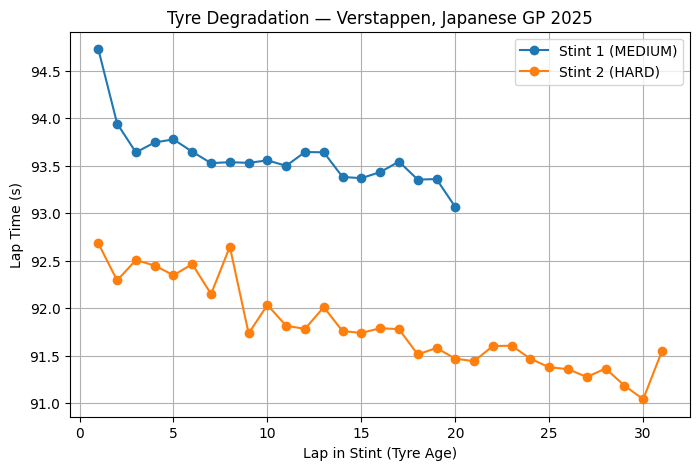

In [44]:
plt.figure(figsize=(8, 5))

for stint_id, stint_df in clean_laps.groupby("Stint"):
    plt.plot(
        stint_df["lap_in_stint"],
        stint_df["lap_time_s"],
        marker="o",
        label=f"Stint {int(stint_id)} ({stint_df['Compound'].iloc[0]})"
    )

plt.xlabel("Lap in Stint (Tyre Age)")
plt.ylabel("Lap Time (s)")
plt.title("Tyre Degradation — Verstappen, Japanese GP 2025")
plt.legend()
plt.grid(True)
plt.show()

##### Linear regression model

###### For each stint:
###### ## Fit a linear model
###### ## Compute residuals
###### ## Inspect where and why the model fails

In [45]:
from sklearn.linear_model import LinearRegression

In [49]:
results = {}

for stint_id, stint_df in clean_laps.groupby("Stint"):
    x = stint_df[["lap_in_stint"]].values
    y = stint_df["lap_time_s"].values

    model = LinearRegression()
    model.fit(x,y)

    y_pred = model.predict(x)
    residuals = y - y_pred
    
results[stint_id] = {
    "model" : model,
    "data" : stint_df,
    "y_pred" : y_pred,
    "residuals" : residuals
}

print(f"\nStint {int(stint_id)} ({stint_df['Compound'].iloc[0]})")
print(f"β0 (intercept): {model.intercept_:.3f}")
print(f"β1 (slope):     {model.coef_[0]:.4f} s/lap")


Stint 2 (HARD)
β0 (intercept): 92.524
β1 (slope):     -0.0453 s/lap


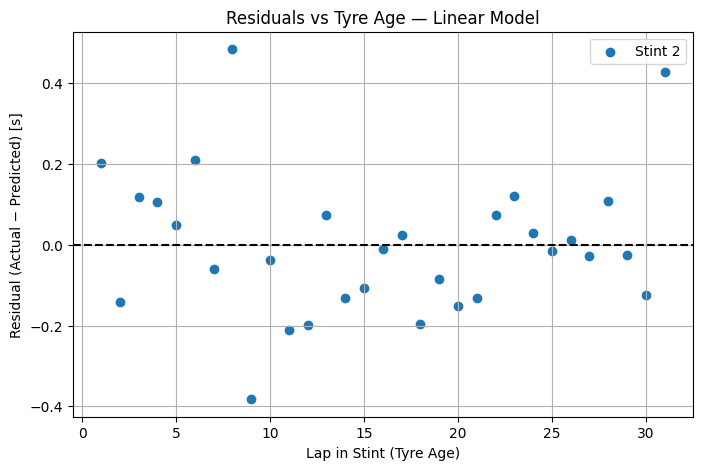

In [54]:
plt.figure(figsize=(8,5))

for stint_id, res in results.items():
    plt.scatter(
        res["data"]["lap_in_stint"],
        res["residuals"],
        label=(f"Stint {int(stint_id)}")
    )

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Lap in Stint (Tyre Age)")
plt.ylabel("Residual (Actual − Predicted) [s]")
plt.title("Residuals vs Tyre Age — Linear Model")
plt.legend()
plt.grid(True)
plt.show()

##### Quadratic expression implementation